# SCNIEC+

This notebook runs the SCENIC+ framework for unpaired scRNA-seq and scATAC-seq on the tumor cells from the Spermatogenesis Mouse dataset 

- input:
  - 

In [ ]:
cistopic_pkl='ATAC_cistopic_obj.pkl'
model_pkl='ATAC_Models_500_iter_LDA.pkl'
numTopics = 45
atac_key='predictedGroup_Un'

In [2]:
#supress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import sys
import os
# sys.path.append('/home/sussmanj/miniconda3/envs/scenicplus/lib/')
_stderr = sys.stderr
null = open(os.devnull,'wb')

%matplotlib inline

In [3]:
import importlib
import sys
import os 
import scanpy as sc
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from scenicplus.scenicplus_class import SCENICPLUS, create_SCENICPLUS_object
from scenicplus.loom import *
from scenicplus.preprocessing.filtering import *
from pycisTopic.cistopic_class import *
from pycisTopic.lda_models import evaluate_models
from pycisTopic.clust_vis import run_umap
from loomxpy.loomxpy import SCopeLoom
from pycisTopic.loom import *
import itertools
import anndata
import pickle
import dill
from pycisTopic.clust_vis import *
from pycisTopic.topic_binarization import *
from pycisTopic.diff_features import *
from pycisTopic.lda_models import run_cgs_models_mallet
import scipy.sparse as sp
import scipy.io as spio
import pyranges as pr
import numpy as  np
from pycistarget.utils import region_names_to_coordinates
from pycisTopic.lda_models import run_cgs_models
from scenicplus.wrappers.run_pycistarget import run_pycistarget
import pybiomart as pbm
from scenicplus.preprocessing.filtering import apply_std_filtering_to_eRegulons
from scenicplus.eregulon_enrichment import score_eRegulons
import seaborn as sns
from scenicplus.plotting.dotplot import heatmap_dotplot
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape
from scenicplus.RSS import *
from scenicplus.plotting.correlation_plot import *
from pycisTopic.diff_features import find_highly_variable_features
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape
import seaborn as sns
import sklearn
from scenicplus.differentiation_potential import *

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-06 07:27:50,050	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [4]:
# #Load cisTopic object
cistopic_obj = pickle.load(open(cistopic_pkl, 'rb'))
print(cistopic_obj)
#Load models 
models = pickle.load(open(model_pkl, 'rb'))

CistopicObject from project cisTopic with n_cells × n_regions = 17079 × 154855


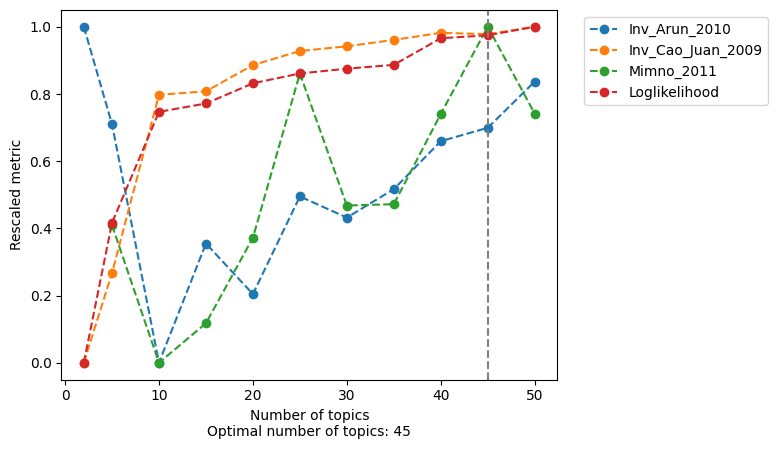

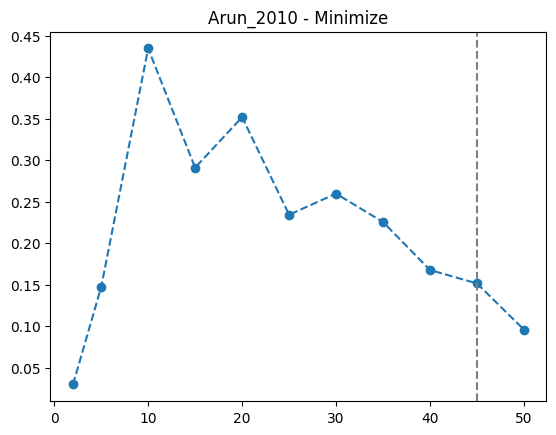

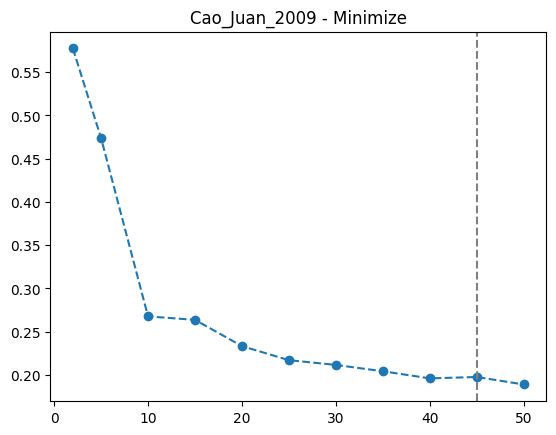

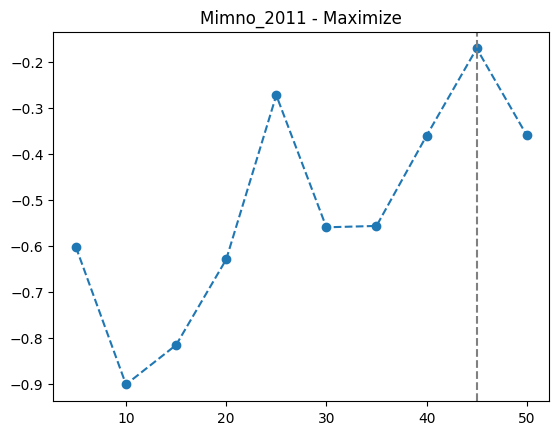

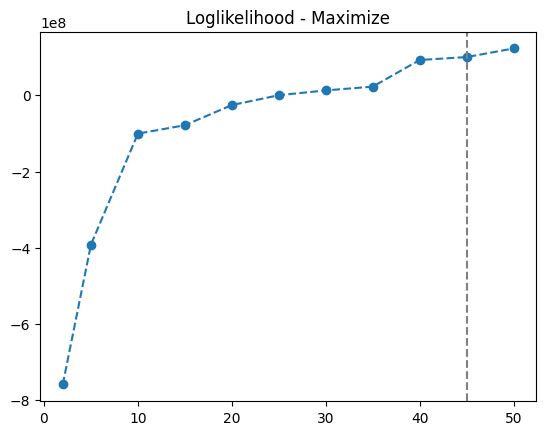

In [ ]:
# model = evaluate_models(models,
#                      select_model = numTopics,
#                      return_model = True,
#                      metrics = ['Arun_2010','Cao_Juan_2009', 'Minmo_2011', 'loglikelihood'],
#                      plot_metrics = False)
model = evaluate_models(models,
                     select_model = numTopics,
                     return_model = True,
                     metrics = ['Arun_2010','Cao_Juan_2009', 'Minmo_2011', 'loglikelihood'],
                     plot_metrics = True,
                     save = "model_metrics.png")

For scATAC-seq data models, the most helpful methods are **Minmo** (topic coherence) and the **log-likelihood** in the last iteration.
- Arun_2010: The better the model, the **lower** the metric.
- Cao_Juan_2009: The better the model, the **lower** the metric.
- Minmo_2011: The better the model, the **higher** coherence.
- loglikelihood: The better the model, the **higher** coherence.

In [8]:
#Add model to cisTopic object and save again 
cistopic_obj.add_LDA_model(model)
pickle.dump(cistopic_obj,
            open('ATAC_cistopic_obj_with_model.pkl', 'wb'))

In [9]:
#Run UMAP
run_umap(cistopic_obj, target = "cell", scale = True)

2026-05-06 07:32:49,290 cisTopic     INFO     Running UMAP


/usr/local/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.


Visualization

In [10]:
atac_key

'sctype'

In [11]:
print(cistopic_obj.cell_data.columns.tolist())

['cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'DoubletEnrichment', 'DoubletScore', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'PassQC', 'PromoterRatio', 'ReadsInPromoter', 'ReadsInTSS', 'Sample', 'TSSEnrichment', 'Clusters', 'ReadsInPeaks', 'FRIP', 'Module.Scutellum2', 'Module.Scutellum1', 'Module.Seed_coat1', 'Module.Seed_coat2', 'Module.Radicle', 'Module.Coleoptile', 'Module.Coleoptile_L1_epidermis', 'Module.Companion_cell', 'Module.Aleurone1', 'Module.Aleurone2', 'Module.Endosperm', 'predictedCell_Un', 'predictedGroup_Un', 'predictedScore_Un', 'predictedGroup_Un_max']


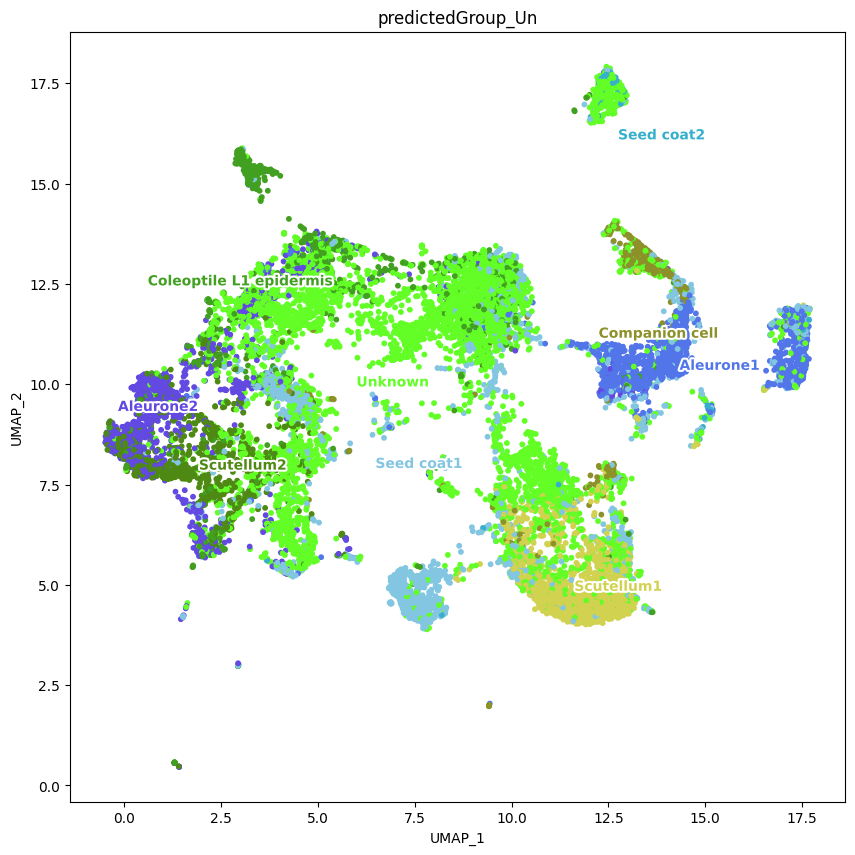

2026-05-06 07:34:06,231 fontTools.subset INFO     maxp pruned
2026-05-06 07:34:06,243 fontTools.subset INFO     cmap pruned
2026-05-06 07:34:06,244 fontTools.subset INFO     kern dropped
2026-05-06 07:34:06,244 fontTools.subset INFO     post pruned
2026-05-06 07:34:06,245 fontTools.subset INFO     FFTM dropped
2026-05-06 07:34:06,248 fontTools.subset INFO     GPOS pruned
2026-05-06 07:34:06,251 fontTools.subset INFO     GSUB pruned
2026-05-06 07:34:06,257 fontTools.subset INFO     glyf pruned
2026-05-06 07:34:06,258 fontTools.subset INFO     Added gid0 to subset
2026-05-06 07:34:06,258 fontTools.subset INFO     Added first four glyphs to subset
2026-05-06 07:34:06,259 fontTools.subset INFO     Closing glyph list over 'GSUB': 26 glyphs before
2026-05-06 07:34:06,259 fontTools.subset INFO     Glyph names: ['.notdef', '.null', 'A', 'G', 'M', 'P', 'U', 'c', 'd', 'e', 'five', 'i', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 'seven', 'space', 't', 'two', 'u', 'underscore', 'zero

In [12]:
plot_metadata(
    cistopic_obj,
    reduction_name = 'UMAP',
    variables = [atac_key],
    figsize = (10, 10), 
    save = "UMAP_CisTopics.png")

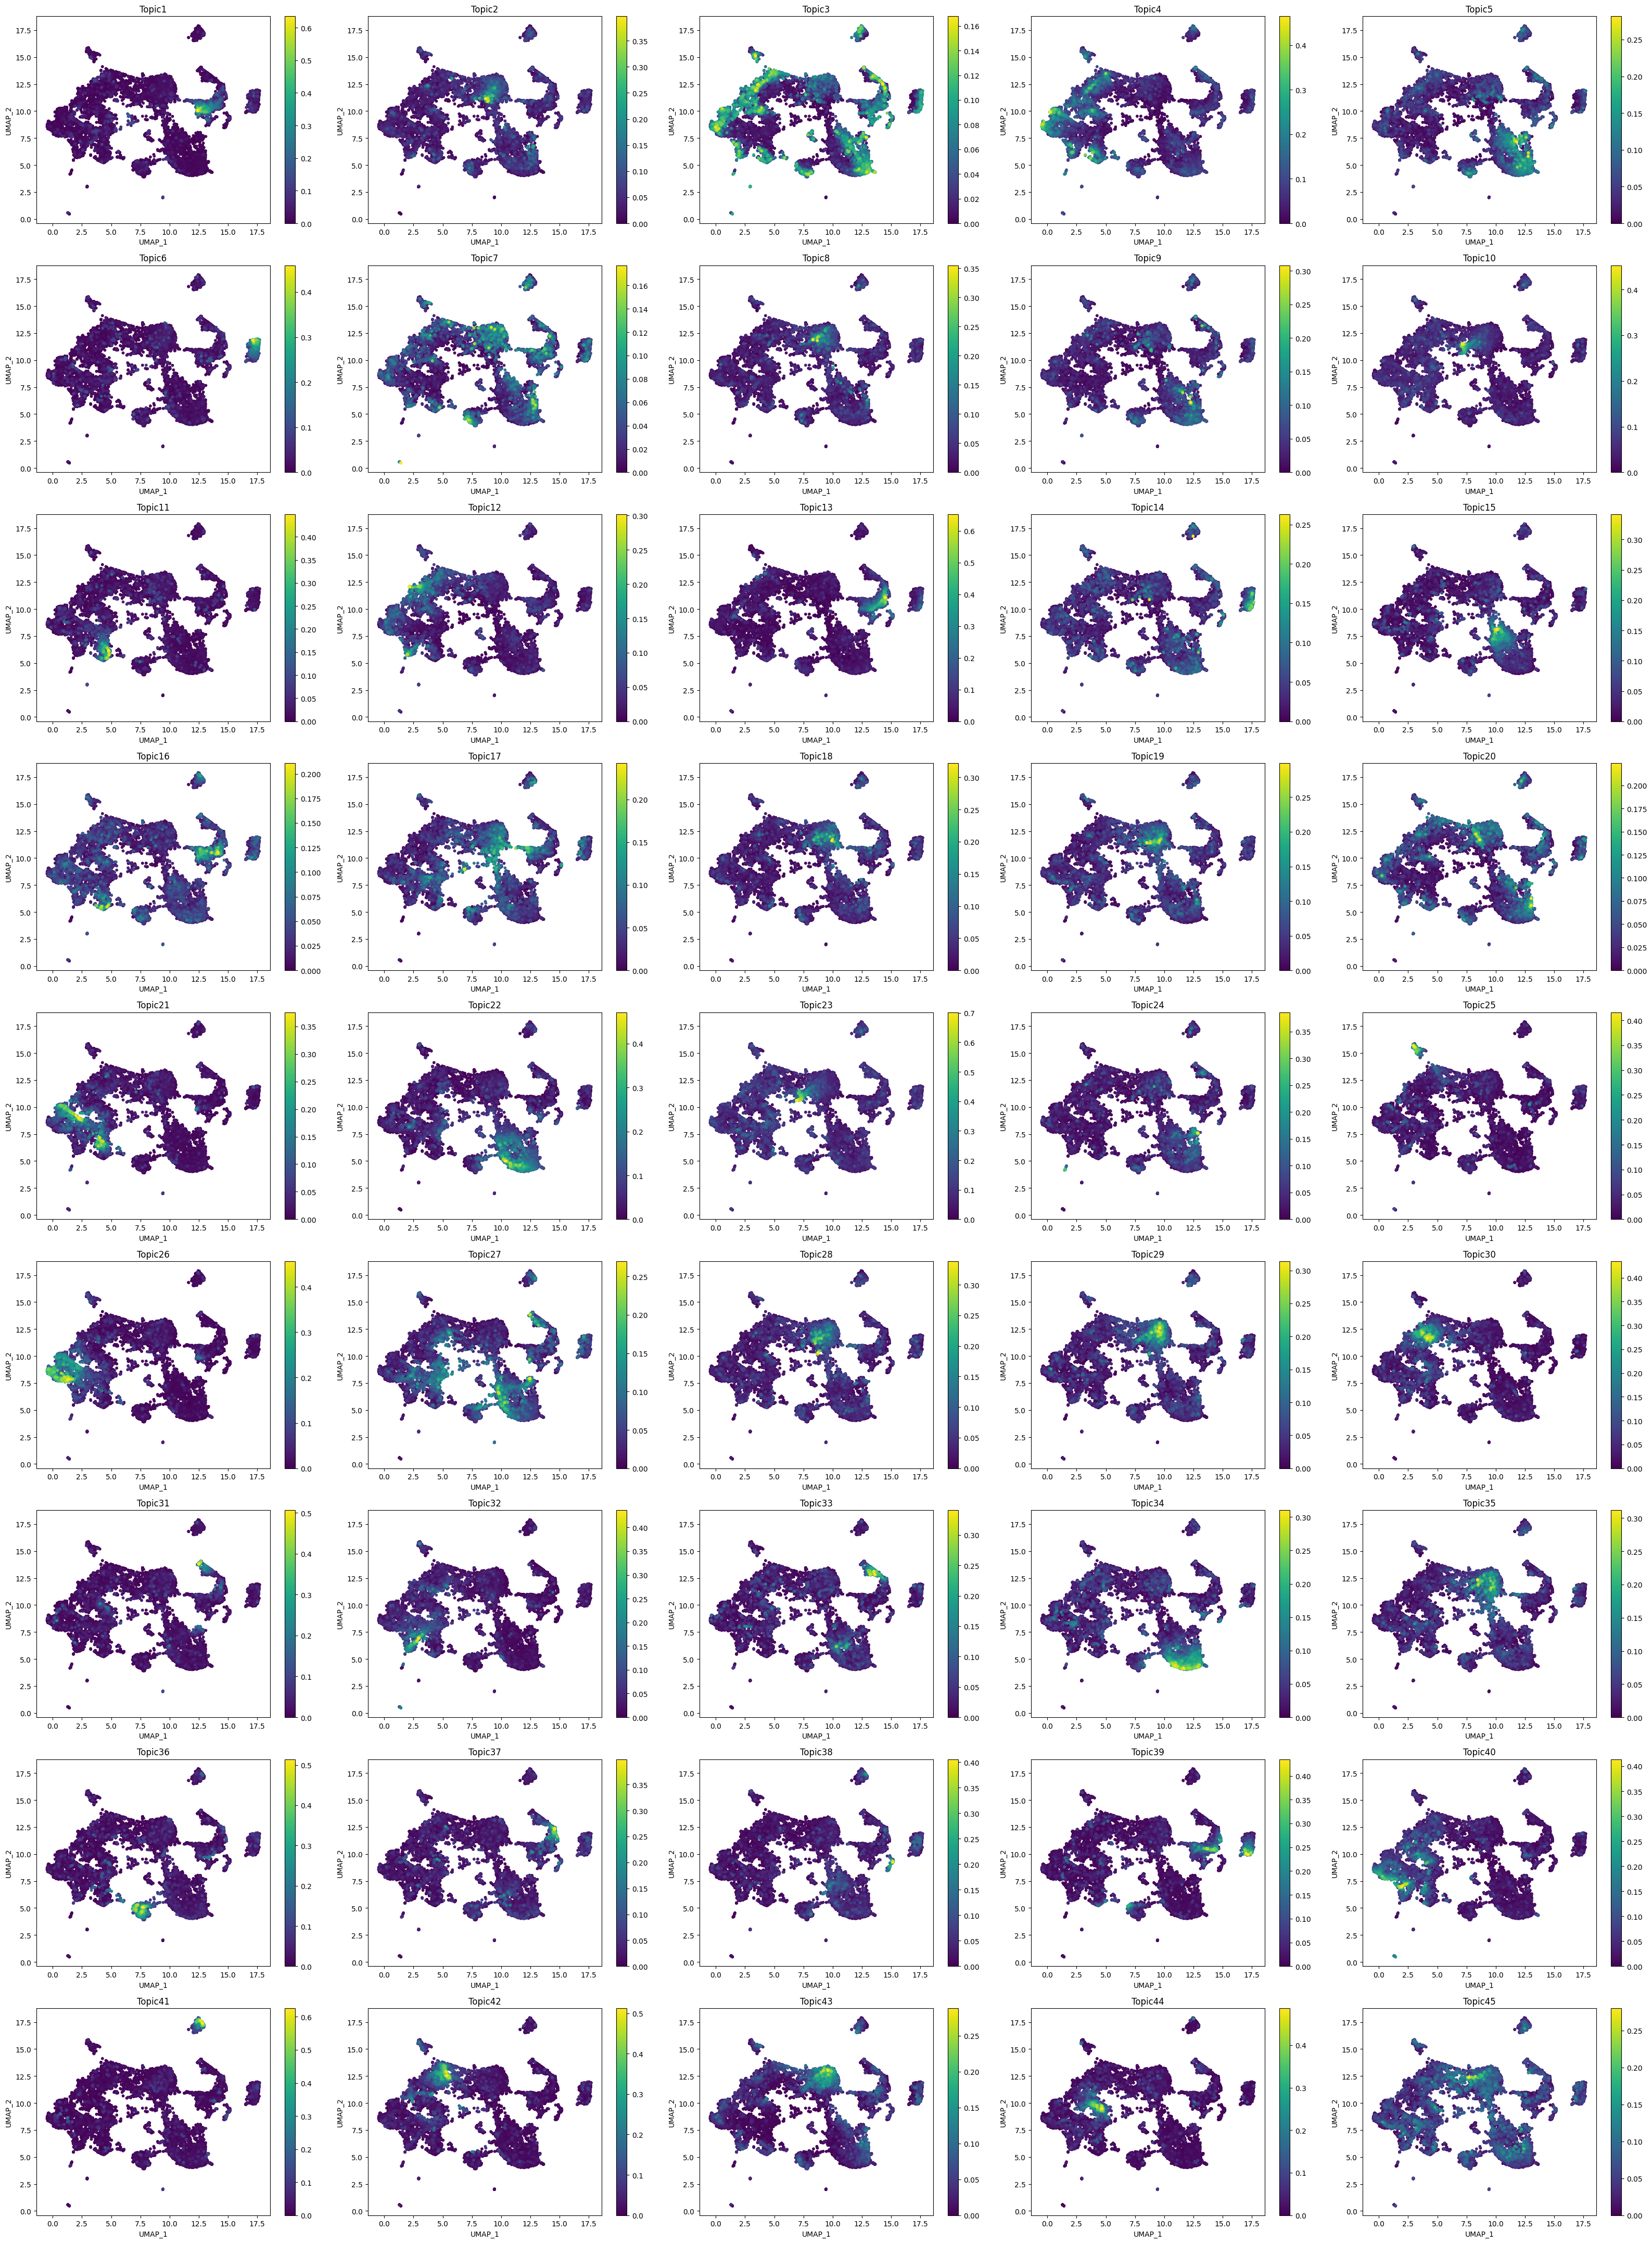

In [13]:
plot_topic(cistopic_obj, reduction_name = 'UMAP', num_columns = 5, 
           save = "FeaturePlot_CisTopics.png")

Inferring candidate enhancer regions

In [14]:
# #Load cisTopic object
# cistopic_obj = pickle.load(open('ATAC_cistopic_obj_with_model.pkl', 'rb'))
print(cistopic_obj)

CistopicObject from project cisTopic with n_cells × n_regions = 17079 × 154855


In [15]:
#Binarize topics, using the 'otsu' method
region_bin_topics_otsu = binarize_topics(cistopic_obj, method='otsu')
region_bin_topics_top3k = binarize_topics(cistopic_obj, method='ntop', ntop = 3000)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
#Calculating DARs per cell type 
imputed_acc_obj = impute_accessibility(cistopic_obj, selected_cells=None, selected_regions=None, scale_factor=10**6)
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)
variable_regions = find_highly_variable_features(normalized_imputed_acc_obj, plot = False)
markers_dict = find_diff_features(cistopic_obj, imputed_acc_obj, variable=atac_key, var_features=variable_regions, split_pattern = '-')

2026-05-06 07:39:08,713 cisTopic     INFO     Imputing region accessibility
2026-05-06 07:39:08,714 cisTopic     INFO     Impute region accessibility for regions 0-20000
2026-05-06 07:39:11,801 cisTopic     INFO     Impute region accessibility for regions 20000-40000
2026-05-06 07:39:14,946 cisTopic     INFO     Impute region accessibility for regions 40000-60000
2026-05-06 07:39:18,075 cisTopic     INFO     Impute region accessibility for regions 60000-80000
2026-05-06 07:39:21,197 cisTopic     INFO     Impute region accessibility for regions 80000-100000
2026-05-06 07:39:24,425 cisTopic     INFO     Impute region accessibility for regions 100000-120000
2026-05-06 07:39:27,568 cisTopic     INFO     Impute region accessibility for regions 120000-140000
2026-05-06 07:39:30,686 cisTopic     INFO     Impute region accessibility for regions 140000-160000
2026-05-06 07:39:33,062 cisTopic     INFO     Done!
2026-05-06 07:39:33,063 cisTopic     INFO     Normalizing imputed data
2026-05-06 07:

In [ ]:
#Save results 
pickle.dump(region_bin_topics_otsu, open('region_bin_topics_otsu.pkl', 'wb'))
pickle.dump(region_bin_topics_top3k, open('region_bin_topics_top3k.pkl', 'wb'))

In [ ]:
os.makedirs("region_sets", exist_ok = True)
os.makedirs(os.path.join("region_sets", "Topics_otsu"), exist_ok = True)
os.makedirs(os.path.join("region_sets", "Topics_top_3k"), exist_ok = True)
os.makedirs(os.path.join("region_sets", "DARs_cell_type"), exist_ok = True)

In [ ]:
for topic in region_bin_topics_otsu:
    region_names_to_coordinates(
        region_bin_topics_otsu[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join("region_sets", "Topics_otsu", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [ ]:
for topic in region_bin_topics_top3k:
    region_names_to_coordinates(
        region_bin_topics_top3k[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join("region_sets", "Topics_top_3k", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [ ]:
for cell_type in markers_dict:
    region_names_to_coordinates(
        markers_dict[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join("region_sets", "DARs_cell_type", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

Save RNA to anndata format 

In [ ]:
# #Load RNA data
# path_to_loom = '/mnt/isilon/tan_lab/sussmanj/Temp/ETP_ALL/SCENICPlus/Data_SCENICplus/TALL_BMP_TSpec_RNA.loom'
# rna_anndata = sc.read_loom(path_to_loom)
# rna_anndata.raw = rna_anndata
# rna_anndata.write("/mnt/isilon/tan_lab/sussmanj/Temp/ETP_ALL/SCENICPlus/Data_SCENICplus/TALL_BMP_TSpec_RNA.h5ad")

In [ ]:
# #Load RNA data
# path_to_loom = '/mnt/isilon/tan_lab/sussmanj/Temp/ETP_ALL/SCENICPlus/Data_SCENICplus/TALL_ETP_Subtype_RNA.loom'
# rna_anndata = sc.read_loom(path_to_loom)
# rna_anndata.raw = rna_anndata
# rna_anndata.write("/mnt/isilon/tan_lab/sussmanj/Temp/ETP_ALL/SCENICPlus/Data_SCENICplus/TALL_ETP_Subtype_RNA.h5ad")

In [ ]:
# rna_anndata